# Average Shortest Paths Notebook (Using CRSP Data)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from ts2vg import HorizontalVG, NaturalVG

In [2]:
NUM_COL = 'true_prc'
DATE_COL = 'dlycaldt'
TICKER_COL1 = 'permno'
TICKER_COL2 = 'ticker'

In [3]:
data = pd.read_csv('./data/crsp_dsf.csv')
data[DATE_COL] = data[DATE_COL].astype('datetime64[s]')
data = data.dropna(subset='dlyclose').reset_index(drop=True)
data['dlyvol'] = data['dlyvol'].fillna(0)
data['tot_shares'] = (data['dlycap'] / data['dlyprc']).round(0)
data[NUM_COL] = data['dlyclose'] * data['tot_shares'] / 1000000
data.head()

C:\Users\jgte2\AppData\Local\Temp\ipykernel_22772\846092833.py:1: DtypeWarning: Columns (28) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('./data/crsp_dsf.csv')


,permno,hdrcusip,permco,siccd,nasdissuno,yyyymmdd,sharetype,securitytype,securitysubtype,usincflg,...,dlymmcnt,dlyprcvol,dlycumfacpr,dlycumfacshr,cusip,ticker,exchangetier,shrout,tot_shares,true_prc
0,10001,36720410,7953,4925,10398,20100104,NS,EQTY,COM,Y,...,NaN,189625.0,1.0,1.0,29269V10,EGAS,NaN,4361,4361.0,0.044700
1,10002,05978R10,7954,6020,10399,20100104,NS,EQTY,COM,Y,...,27.0,86319.5,1.0,1.0,05978R10,BTFG,Q,17634,17634.0,0.054665
2,10025,00103110,7975,3081,10432,20100104,NS,EQTY,COM,Y,...,25.0,1334002.8,1.0,1.0,00103110,AEPI,Q,6852,6852.0,0.271065
3,10026,46603210,7976,2052,10433,20100104,NS,EQTY,COM,Y,...,29.0,1923931.8,1.0,1.0,46603210,JJSF,Q,18374,18374.0,0.738635
4,10028,29402E10,7978,5094,22226,20100104,NS,EQTY,COM,Y,...,NaN,5460.4,1.0,1.0,23323G10,DGSE,NaN,9834,9834.0,0.013769


In [4]:
tickers = data[[TICKER_COL1, TICKER_COL2]].drop_duplicates().reset_index(drop=True).values

In [5]:
TICKER = (90319, "GOOGL")

In [8]:
### avsp ==> Average Shortest Path
def ts2vg_shortest_path_features(arr, lookback):
    avsp_p = np.zeros(len(arr))
    avsp_n = np.zeros(len(arr))

    avsp_p[:] = np.nan
    avsp_n[:] = np.nan

    for i in range(lookback, len(arr)):
        dat = arr[i - lookback + 1: i+1]

        pos = NaturalVG()
        pos.build(dat)

        neg = NaturalVG()
        neg.build(-dat)

        neg = neg.as_networkx()
        pos = pos.as_networkx()
        
        avsp_p[i] = nx.average_shortest_path_length(pos)
        avsp_n[i] = nx.average_shortest_path_length(neg)

    return avsp_p, avsp_n

In [12]:
df = data[(data[TICKER_COL1] == TICKER[0]) & (data[TICKER_COL2] == TICKER[1])].copy()
### Subset for initial testing
df = df.iloc[:200, :]
df = df.sort_values(DATE_COL).set_index(DATE_COL)

In [13]:
lookback = 3
arr = df[NUM_COL].to_numpy()

### Get shortest path features
pos, neg = ts2vg_shortest_path_features(arr, lookback)

df["pos"] = pos
df["neg"] = neg
df = df.dropna(subset=[NUM_COL, TICKER_COL1, TICKER_COL2, 'pos', 'neg']).reset_index()

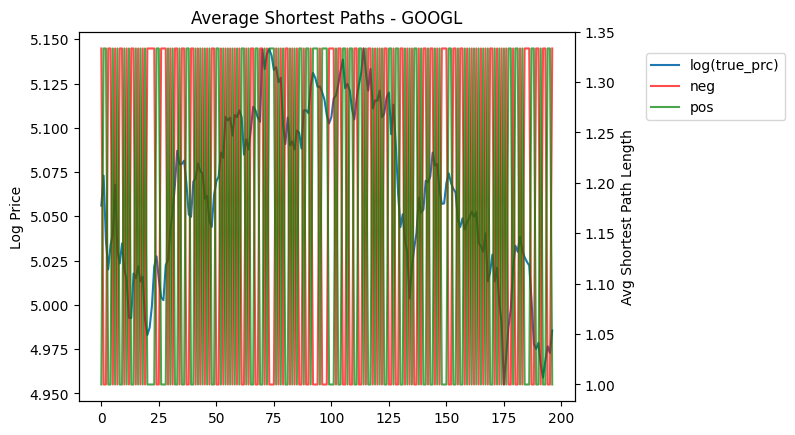

In [14]:
fig, ax1 = plt.subplots()

ax1.plot(np.log(df[NUM_COL]), label=f"log({NUM_COL})")
ax1.set_ylabel("Log Price")

ax2 = ax1.twinx()
ax2.plot(df["neg"], color="red", label="neg", alpha=0.7)
ax2.plot(df["pos"], color="green", label="pos", alpha=0.7)
ax2.set_ylabel("Avg Shortest Path Length")

fig.legend(loc="upper left", bbox_to_anchor=(1, 0.85))
plt.title(f"Average Shortest Paths - {df['ticker'].values[0]}")
plt.show()

In [5]:
def get_avsp_one_stock(ticker, data=data, lookback=7, num_col=NUM_COL, ret_cols = [DATE_COL, TICKER_COL1, TICKER_COL2, 'pos', 'neg']):
    df = data[(data[TICKER_COL1] == ticker[0]) & (data[TICKER_COL2] == ticker[1])].copy()
    df = df.sort_values(DATE_COL).set_index(DATE_COL)
    arr = df[num_col].to_numpy()

    ### Get shortest path features
    pos, neg = ts2vg_shortest_path_features(arr, lookback)

    df["pos"] = pos
    df["neg"] = neg
    
    cols = ret_cols + [num_col]
    df = df.reset_index()[cols]

    return df.dropna(subset=cols).reset_index(drop=True)


In [6]:
def get_all_avsp(tickers=tickers, data=data, lookback=7, num_col=NUM_COL, ret_cols = [DATE_COL, TICKER_COL1, TICKER_COL2, 'pos', 'neg']):
    all_avsp = pd.DataFrame()
    
    for t in tickers:
        avsp_df = get_avsp_one_stock(ticker=t, data=data, lookback=lookback, num_col=num_col, ret_cols=ret_cols)
        
        if len(all_avsp) == 0:
            all_avsp = avsp_df.copy()
        else:
            all_avsp = pd.concat([all_avsp, avsp_df])
    return all_avsp

In [9]:
lookback=3
all_avsp = get_all_avsp(tickers=tickers, lookback=lookback, ret_cols = [DATE_COL, TICKER_COL1, TICKER_COL2, 'dlyclose', 'tot_shares', 'pos', 'neg'])
all_avsp.to_csv(f"./data/all_avsp_crsp_window_{lookback}.csv", index=False)